In [1]:
import os
import cv2
import json
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.utils import save_image

from utils.model2_explain import ObjectStateNet

In [2]:
def load_model(backbone, attn, num_classes, checkpoint, device="cuda"):
    state_dict = torch.load(checkpoint, map_location=device)
    model = ObjectStateNet(
        backbone_name=backbone,
        num_classes=num_classes,
        pretrained=True,
        attn_type=attn,
        use_residual=True,
        fusion="object"
    )
    model.load_state_dict(state_dict)
    torch.set_grad_enabled(True) 
    model.to(device).eval()
    print(f"✅ Model loaded from {checkpoint}")
    return model

In [3]:
def get_data(ann_file, label2id, img_path_root):
    data = []
    with open(ann_file, "r") as fp:
        raw_data = json.loads(fp.read())
    
    for k, v in raw_data.items():
        img_name = f"{k}.jpg"
        img_path = os.path.join(img_path_root, img_name)
    
        for i, ann in v.items():
            x1,y1,x2,y2 = ann["bbox"] #xyxy
            w = x2 - x1
            h = y2 - y1
            label = ann["label"]
            if label == "Unrelated Region":
                continue
    
            data.append({
                "img_path": img_path,
                "bbox": [x1, y1, w, h],
                "label": label2id[label]
            })
            
    return data

In [4]:
def img_preprocess(item):
    img_path = item["img_path"]
    bbox = item["bbox"]
    label = item["label"]
    
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    original_img = Image.open(img_path).convert("RGB")
    img_W, img_H = original_img.size
    x1, y1, w, h = bbox
    x2 = x1 + w
    y2 = y1 + h
    cropped_region = original_img.crop((x1, y1, x2, y2))

    image = test_transform(original_img)
    cropped_region = test_transform(cropped_region)

    bbox_normed = torch.tensor([
        x1 / img_W,
        y1 / img_H,
        x2 / img_W,
        y2 / img_H
    ], dtype=torch.float32)

    return {
        "original": image.unsqueeze(0).cuda(),
        "crop": cropped_region.unsqueeze(0).cuda(),
        "bbox": bbox_normed.unsqueeze(0).cuda(),
        "label": label
    }

## 2.1 ViT相关代码

In [51]:
@torch.no_grad()
def grab_vit_tokens_multi(vit_backbone, x, last_k_layers=(2,3,4,5,6)):
    """
    从 torchvision ViT 的 encoder.layers 中抓取多层输出的 token。
    last_k_layers: 例如 (2,3,4,5,6) 表示抓倒数第2~6层（顺序不敏感）
    返回:
      cls_dict:   {layer_idx: [B,1,D]}
      patch_dict: {layer_idx: [B,196,D]}  (ViT-B/16@224 => 14*14)
    """
    device = next(vit_backbone.parameters()).device
    dtype  = next(vit_backbone.parameters()).dtype
    x = x.to(device=device, dtype=dtype)

    layers = list(vit_backbone.encoder.layers)
    # 计算真实的 layer 索引，如 -2,-3...
    target_ids = sorted({len(layers) - k for k in last_k_layers if 1 <= k <= len(layers)})

    cache = {}  # {layer_idx: tokens[B,N,D]}
    handles = []

    def _hook_factory(idx):
        def _save_tokens(mod, inp, out):
            # out: [B,N,D]
            cache[idx] = out.detach()
        return _save_tokens

    for idx in target_ids:
        h = layers[idx].register_forward_hook(_hook_factory(idx))
        handles.append(h)

    vit_backbone.eval()
    _ = vit_backbone(x)  # 触发所有 hook

    for h in handles:
        h.remove()

    cls_dict = {}
    patch_dict = {}
    for idx in target_ids:
        tokens = cache[idx]              # [B, N, D] (N=197)
        cls_dict[idx]   = tokens[:, :1, :]    # [B,1,D]
        patch_dict[idx] = tokens[:, 1:, :]    # [B,196,D]

    return cls_dict, patch_dict, target_ids


@torch.no_grad()
def cross_attn_probe_multi_cosine(cls_obj_dict, patch_glb_dict, agg='mean', temperature=1.0, eps=1e-6):
    """
    多层“离线 cross-attn”的无参版：用 CLS_obj 与 PATCHES_glb 的余弦相似度，
    得到每层的 14x14 热力图，并做聚合。

    输入:
      cls_obj_dict:   {layer_idx: [B,1,D]}   ← object_extractor 的 CLS
      patch_glb_dict: {layer_idx: [B,196,D]} ← global_extractor 的 PATCH tokens
    返回:
      amap_per_layer: {layer_idx: [B,14,14]}（0~1 归一化）
      amap_agg:       [B,14,14]
    """
    # 取任意张量确认设备/精度
    any_t = next(iter(cls_obj_dict.values()))
    device, dtype = any_t.device, any_t.dtype

    amap_per_layer = {}
    for idx in cls_obj_dict.keys():
        cls = cls_obj_dict[idx].to(device=device, dtype=dtype)         # [B,1,D]
        pts = patch_glb_dict[idx].to(device=device, dtype=dtype)       # [B,196,D]

        # 归一化后做余弦相似度 => [B,196]
        cls_n = F.normalize(cls, dim=-1)        # [B,1,D]
        pts_n = F.normalize(pts, dim=-1)        # [B,196,D]
        sim   = torch.matmul(cls_n, pts_n.transpose(1,2)).squeeze(1)   # [B,196]
        # 可选温度缩放
        sim = sim / max(temperature, eps)

        # 归一化到 0~1，避免 min==max → 全 0
        smin = sim.amin(dim=1, keepdim=True)
        smax = sim.amax(dim=1, keepdim=True)
        sim01 = (sim - smin) / (smax - smin + eps)                     # [B,196]
        amap_per_layer[idx] = sim01.reshape(-1, 14, 14)                # [B,14,14]

    # 聚合（mean/median/max）
    stacks = torch.stack([amap_per_layer[i] for i in sorted(amap_per_layer.keys())], dim=0)  # [L,B,14,14]
    if   agg == 'mean':   amap_agg = stacks.mean(dim=0)
    elif agg == 'median': amap_agg = stacks.median(dim=0).values
    elif agg == 'max':    amap_agg = stacks.max(dim=0).values
    else:                 amap_agg = stacks.mean(dim=0)

    return amap_per_layer, amap_agg

## 2.2 Conv相关代码

In [52]:
@torch.no_grad()
def grab_convnext_spatial_feature(convnext_features, x):
    """
    抓取 ConvNeXt 的 spatial feature map.

    convnext_features:
        通常传入 model.global_extractor.features 或 model.object_extractor.features

    返回:
        feat_map: [B, C, H, W]
    """

    device = next(convnext_features.parameters()).device
    dtype = next(convnext_features.parameters()).dtype
    x = x.to(device=device, dtype=dtype)

    cache = {}

    # 关键：如果 features = Sequential(stage, avgpool)，要抓 features[0]
    target_module = convnext_features[0]

    def hook_fn(module, inputs, output):
        cache["feat"] = output.detach()

    handle = target_module.register_forward_hook(hook_fn)

    convnext_features.eval()
    _ = convnext_features(x)

    handle.remove()

    return cache["feat"]

@torch.no_grad()
def convnext_object_to_global_similarity(feat_object, feat_global, eps=1e-6):
    """
    feat_object: [B, C, H_o, W_o]
    feat_global: [B, C, H_g, W_g]

    返回:
        sim_map: [B, H_g, W_g]
    """

    # object branch: spatial feature map -> object-level vector
    obj_vec = feat_object.mean(dim=(2, 3))  # [B, C]

    # global branch: spatial feature map -> spatial vectors
    B, C, H, W = feat_global.shape
    glb_vecs = feat_global.flatten(2).transpose(1, 2)  # [B, H*W, C]

    # cosine similarity
    obj_vec = F.normalize(obj_vec, dim=-1).unsqueeze(1)  # [B, 1, C]
    glb_vecs = F.normalize(glb_vecs, dim=-1)             # [B, H*W, C]

    sim = torch.matmul(obj_vec, glb_vecs.transpose(1, 2)).squeeze(1)  # [B, H*W]

    # normalize to 0-1 for visualization
    smin = sim.amin(dim=1, keepdim=True)
    smax = sim.amax(dim=1, keepdim=True)
    sim01 = (sim - smin) / (smax - smin + eps)

    sim_map = sim01.reshape(B, H, W)  # [B, H, W]

    return sim_map

def upsample_similarity_map(sim_map, target_size):
    """
    sim_map: [B, H, W]
    target_size: (height, width)
    """
    sim_map_up = F.interpolate(
        sim_map.unsqueeze(1),  # [B, 1, H, W]
        size=target_size,
        mode="bilinear",
        align_corners=False
    )
    return sim_map_up.squeeze(1)  # [B, target_H, target_W]

## 3. get_used_data

In [60]:
def get_data_wrapper(ds_id):
    datasets = [
        "1. gas cylinder",
        "2. working at height",
        "3. worker with hardhat & vest",
        "4. working with eye protection",
        "5. vehicle"
    ]
    dataset = datasets[ds_id]
    test_img_path = f"./config_file/{dataset}/testImgs/"
    test_ann_file = f"./config_file/{dataset}/testImgs/bboxes_{ds_id + 1}.json"
    labels_file = f"./config_file/{dataset}/testImgs/labels_{ds_id + 1}.json"
    
    with open(labels_file, "r") as fp:
        label2id = json.loads(fp.read())
    num_classes = len(label2id)
    
    data = get_data(ann_file=test_ann_file, label2id=label2id, img_path_root=test_img_path)
    return data, num_classes

In [81]:
def save_vit_img(amap_per_layer, amap_agg, layers, model, item=None, save_path=None):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    # 1. 每一层 similarity map
    for j, idx in enumerate(layers):
        axes[j].imshow(
            amap_per_layer[idx][0].detach().cpu().numpy(),
            cmap="jet"
        )
        axes[j].set_title(
            f"Layer -{len(model.object_extractor.features.encoder.layers)-idx} (idx {idx})"
        )
        axes[j].axis("off")

    # 2. Aggregated mean：最后一行第一个
    axes[6].imshow(
        amap_agg[0].detach().cpu().numpy(),
        cmap="jet"
    )
    axes[6].set_title("Aggregated (mean)")
    axes[6].axis("off")

    # 3. Original image：最后一行第二个
    if item is not None:
        img = Image.open(item["img_path"]).convert("RGB")

        axes[7].imshow(img)
        axes[7].set_title("Original image")
        axes[7].axis("off")

        # 4. Cropped region：最后一行第三个
        x, y, w, h = item["bbox"]
        crop = img.crop((x, y, x + w, y + h))

        axes[8].imshow(crop)
        axes[8].set_title("Cropped region")
        axes[8].axis("off")
    else:
        axes[7].axis("off")
        axes[8].axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        
    plt.close()

In [ ]:
# def save_vit_overlapped_img()
#     import cv2, numpy as np
#     from pytorch_grad_cam.utils.image import show_cam_on_image
    
#     rgb_global = np.float32(Image.open(item["img_path"]).convert("RGB").resize((224, 224))) / 255
    
#     hmap = amap_agg[0].detach().cpu().numpy()
#     hmap_up = cv2.resize(hmap, (224, 224), interpolation=cv2.INTER_CUBIC)
#     vis = show_cam_on_image(rgb_global.astype(np.float32), hmap_up, use_rgb=True)
#     plt.imshow(vis); 
#     plt.axis('off'); 
#     plt.show()

In [82]:
def save_conv_img(sim_map, item=None, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # 1. sim_map
    hmap = sim_map[0].detach().cpu().numpy()  # [7, 7]

    axes[0].imshow(hmap, cmap="jet")
    axes[0].set_title("Similarity map")
    axes[0].axis("off")

    # 2. original image
    img = Image.open(item["img_path"]).convert("RGB")

    axes[1].imshow(img)
    axes[1].set_title("Original image")
    axes[1].axis("off")

    # 3. cropped region
    x, y, w, h = item["bbox"]
    crop = img.crop((x, y, x + w, y + h))

    axes[2].imshow(crop)
    axes[2].set_title("Cropped region")
    axes[2].axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.close()

In [84]:
backbones = ["vit_b_16",  "convnext_large",]#

checkpoints = {
    "vit_b_16":[
        "./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_vit_b_16_bicross_model_bbtrainable.pth",
    ],
    "convnext_large":[
        "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_convnext_large_bicross_model_bbtrainable.pth",
    ]
}


for backbone in backbones:
    for ds_id in range(0,5):
        checkpoint = checkpoints[backbone][ds_id]
        data, num_classes = get_data_wrapper(ds_id=ds_id)
        model = load_model(
            backbone = backbone,
            attn = "bicross",
            num_classes = num_classes,
            checkpoint = checkpoint
        )
        folder_path = f"./internal_analysis/{backbone}/{ds_id}/"
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
        print(f"---processing--> {backbone} - {ds_id}")
        
        for i, item in enumerate(data):
            inputs = img_preprocess(item)
            img_global = inputs["original"]   # 整张图 (global image) : Tensor[B,3,224,224]
            img_object = inputs["crop"]       # 裁剪区域 (cropped object image)
            bbox = inputs["bbox"]             # 归一化目标框 [x1,y1,x2,y2]
            label = inputs["label"]

            if backbone == "vit_b_16":
                vit_g = model.global_extractor.features
                vit_o = model.object_extractor.features
                
                cls_o_dict, _o_patches, layers = grab_vit_tokens_multi(model.object_extractor.features, img_object, last_k_layers=(1,2,3,4,5,6))
                _, patch_g_dict, _            = grab_vit_tokens_multi(model.global_extractor.features,  img_global, last_k_layers=(1,2,3,4,5,6))
                
                amap_per_layer, amap_agg = cross_attn_probe_multi_cosine(cls_o_dict, patch_g_dict, agg='mean', temperature=1.0)
                
                img_id = item["img_path"].split("/")[-1].split(".")[0]
                img_path = folder_path + f"{label}_{img_id}_{i}.jpg"
                
                save_vit_img(amap_per_layer, amap_agg, layers=layers, model=model, item=item, save_path=img_path)
                
            elif backbone == "convnext_large":
                conv_g = model.global_extractor.features
                conv_o = model.object_extractor.features
                
                feat_object = grab_convnext_spatial_feature(conv_o, img_object)
                feat_global = grab_convnext_spatial_feature(conv_g, img_global)
                
                sim_map = convnext_object_to_global_similarity(feat_object, feat_global)
                
                img_id = item["img_path"].split("/")[-1].split(".")[0]
                img_path = folder_path + f"{label}_{img_id}_{i}.jpg"

                save_conv_img(sim_map, item=item, save_path=img_path)

✅ Model loaded from ./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 0
✅ Model loaded from ./config_file/explanable_results/models/1_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 1
✅ Model loaded from ./config_file/explanable_results/models/2_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 2
✅ Model loaded from ./config_file/explanable_results/models/3_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 3
✅ Model loaded from ./config_file/explanable_results/models/4_vit_b_16_bicross_model_bbtrainable.pth
---processing--> vit_b_16 - 4
✅ Model loaded from ./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth
---processing--> convnext_large - 0
✅ Model loaded from ./config_file/explanable_results/models/1_convnext_large_bicross_model_bbtrainable.pth
---processing--> convnext_large - 1
✅ Model loaded from ./config_file/explanable_results/models

In [211]:
## 获取数据
datasets = [
    "1. gas cylinder",
    "2. working at height",
    "3. worker with hardhat & vest",
    "4. working with eye protection",
    "5. vehicle"
]
backbones = ["vit_b_16","convnext_large"] 
checkpoints = {
    "vit_b_16":[
        "./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_vit_b_16_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_vit_b_16_bicross_model_bbtrainable.pth",
    ],
    "convnext_large":[
        "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/1_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/2_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/3_convnext_large_bicross_model_bbtrainable.pth",
        "./config_file/explanable_results/models/4_convnext_large_bicross_model_bbtrainable.pth",
    ]
}

ds_id = 4
dataset = datasets[ds_id]
test_img_path = f"./config_file/{dataset}/testImgs/"
test_ann_file = f"./config_file/{dataset}/testImgs/bboxes_{ds_id + 1}.json"
labels_file = f"./config_file/{dataset}/testImgs/labels_{ds_id + 1}.json"

with open(labels_file, "r") as fp:
    label2id = json.loads(fp.read())
num_classes = len(label2id)

data = get_data(ann_file=test_ann_file, label2id=label2id, img_path_root=test_img_path)

In [222]:
item_id = 15
item = data[item_id]
inputs = img_preprocess(item)
img_global = inputs["original"]   # 整张图 (global image) : Tensor[B,3,224,224]
img_object = inputs["crop"]       # 裁剪区域 (cropped object image)
bbox = inputs["bbox"]             # 归一化目标框 [x1,y1,x2,y2]
label = inputs["label"] # ==> 这里的类型就是int

## a. 处理ViT的图片可视化

In [219]:
## 定义模型
bb_id = 0
checkpoint = checkpoints[backbones[bb_id]][ds_id]

vit_model = load_model(
    backbone = backbones[bb_id],
    attn = "bicross",
    num_classes = num_classes,
    checkpoint = checkpoint
)
vit_model.eval()
print("Finish Preparation!")

✅ Model loaded from ./config_file/explanable_results/models/4_vit_b_16_bicross_model_bbtrainable.pth
Finish Preparation!


In [223]:
vit_g = vit_model.global_extractor.features
vit_o = vit_model.object_extractor.features

# 1) 抓多层 token：倒数第 2~6 层
cls_o_dict, _o_patches, layers = grab_vit_tokens_multi(vit_model.object_extractor.features, img_object, last_k_layers=(1,2,3,4,5,6))
_, patch_g_dict, _            = grab_vit_tokens_multi(vit_model.global_extractor.features,  img_global, last_k_layers=(1,2,3,4,5,6))

# 2) 计算“CLS_obj → PATCHES_glb”的无参注意力并聚合
amap_per_layer, amap_agg = cross_attn_probe_multi_cosine(cls_o_dict, patch_g_dict, agg='mean', temperature=1.0)

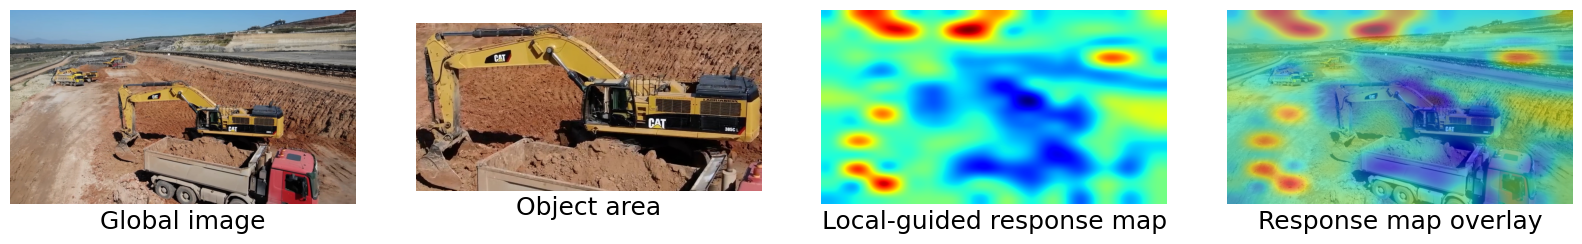

In [224]:
import cv2, numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

rgb_global = Image.open(item["img_path"]).convert("RGB")
w, h = rgb_global.size

rgb_global_np = np.float32(Image.open(item["img_path"]).convert("RGB")) / 255

hmap = amap_per_layer[9][0].detach().cpu().numpy()
hmap_up = cv2.resize(hmap, (w, h), interpolation=cv2.INTER_CUBIC)

# 归一化，显示更稳定
hmap_up = (hmap_up - hmap_up.min()) / (hmap_up.max() - hmap_up.min() + 1e-6)

# plt.figure(figsize=(6, 6))
# plt.imshow(rgb_global_np)
# plt.imshow(hmap_up, cmap="jet", alpha=0.55)
# plt.axis("off")
# plt.show()

# 一行三列绘图
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# 1. Original image
axes[0].imshow(rgb_global)
axes[0].axis("off")
axes[0].text(
    0.5, -0.03,
    "Global image",
    transform=axes[0].transAxes,
    ha="center",
    va="top",
    fontsize=18
)

x, y, w, h = item["bbox"]
crop = rgb_global.crop((x, y, x + w, y + h))

axes[1].imshow(crop)
axes[1].axis("off")
axes[1].text(
    0.5, -0.03,
    "Object area",
    transform=axes[1].transAxes,
    ha="center",
    va="top",
    fontsize=18
)


# 2. Local-guided response map
axes[2].imshow(hmap_up, cmap="jet")
axes[2].axis("off")
axes[2].text(
    0.5, -0.03,
    "Local-guided response map",
    transform=axes[2].transAxes,
    ha="center",
    va="top",
    fontsize=18
)

# 3. Response map overlay
axes[3].imshow(rgb_global)
axes[3].imshow(hmap_up, cmap="jet", alpha=0.55)
# axes[2].set_title("Response map overlay")
axes[3].axis("off")
axes[3].text(
    0.5, -0.03,
    "Response map overlay",
    transform=axes[3].transAxes,
    ha="center",
    va="top",
    fontsize=18
)

plt.tight_layout()

plt.savefig(f"C:/Dropbox/Dropbox/2. myResearch/thesis/figures/Figure 5.20_5.21/vit_{ds_id}.png", dpi=300, bbox_inches="tight", pad_inches=0.05)

plt.show()

## b. 处理Convnext-large的图片可视化

In [203]:
## 定义模型
bb_id = 1
checkpoint = checkpoints[backbones[bb_id]][ds_id]

conv_model = load_model(
    backbone = backbones[bb_id],
    attn = "bicross",
    num_classes = num_classes,
    checkpoint = checkpoint
)
conv_model.eval()
print("Finish Preparation!")

✅ Model loaded from ./config_file/explanable_results/models/3_convnext_large_bicross_model_bbtrainable.pth
Finish Preparation!


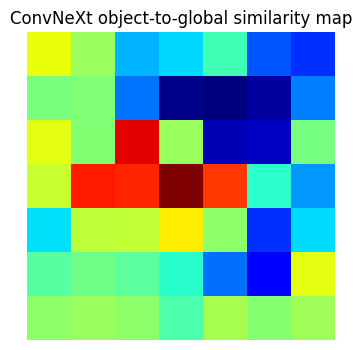

In [225]:
conv_g = conv_model.global_extractor.features
conv_o = conv_model.object_extractor.features

feat_object = grab_convnext_spatial_feature(conv_o, img_object)
feat_global = grab_convnext_spatial_feature(conv_g, img_global)

sim_map = convnext_object_to_global_similarity(feat_object, feat_global)

plt.figure(figsize=(4, 4))
plt.imshow(sim_map[0].detach().cpu().numpy(), cmap="jet")
plt.axis("off")
plt.title("ConvNeXt object-to-global similarity map")
plt.show()

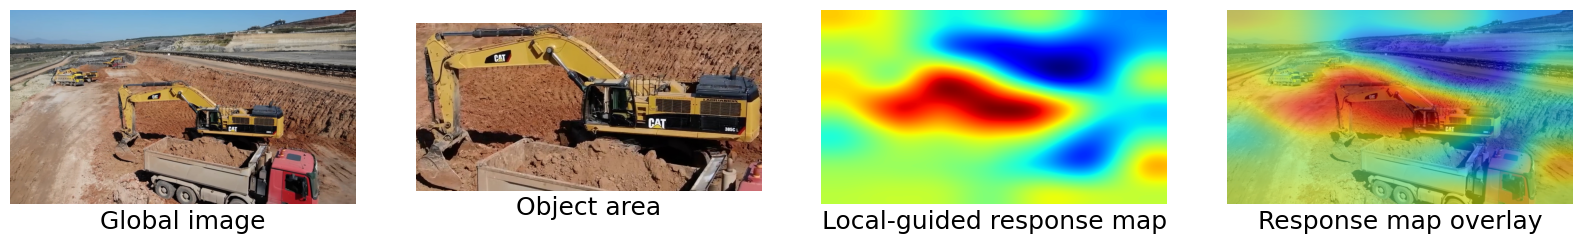

In [226]:
rgb_global = Image.open(item["img_path"]).convert("RGB")
w, h = rgb_global.size

rgb_global_np = np.float32(Image.open(item["img_path"]).convert("RGB")) / 255


hmap = sim_map[0].detach().cpu().numpy()
hmap_up = cv2.resize(hmap, (w, h), interpolation=cv2.INTER_CUBIC)

# 归一化，显示更稳定
hmap_up = (hmap_up - hmap_up.min()) / (hmap_up.max() - hmap_up.min() + 1e-6)

# plt.figure(figsize=(6, 6))
# plt.imshow(rgb_global_np)
# plt.imshow(hmap_up, cmap="jet", alpha=0.55)
# plt.axis("off")
# plt.show()

# 一行三列绘图
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# 1. Original image
axes[0].imshow(rgb_global)
axes[0].axis("off")
axes[0].text(
    0.5, -0.03,
    "Global image",
    transform=axes[0].transAxes,
    ha="center",
    va="top",
    fontsize=18
)

x, y, w, h = item["bbox"]
crop = rgb_global.crop((x, y, x + w, y + h))

axes[1].imshow(crop)
axes[1].axis("off")
axes[1].text(
    0.5, -0.03,
    "Object area",
    transform=axes[1].transAxes,
    ha="center",
    va="top",
    fontsize=18
)


# 2. Local-guided response map
axes[2].imshow(hmap_up, cmap="jet")
axes[2].axis("off")
axes[2].text(
    0.5, -0.03,
    "Local-guided response map",
    transform=axes[2].transAxes,
    ha="center",
    va="top",
    fontsize=18
)

# 3. Response map overlay
axes[3].imshow(rgb_global)
axes[3].imshow(hmap_up, cmap="jet", alpha=0.55)
# axes[2].set_title("Response map overlay")
axes[3].axis("off")
axes[3].text(
    0.5, -0.03,
    "Response map overlay",
    transform=axes[3].transAxes,
    ha="center",
    va="top",
    fontsize=18
)

plt.tight_layout()

plt.savefig(f"C:/Dropbox/Dropbox/2. myResearch/thesis/figures/Figure 5.20_5.21/conv_{ds_id}.png", dpi=300, bbox_inches="tight", pad_inches=0.05)

plt.show()

✅ Model loaded from ./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth


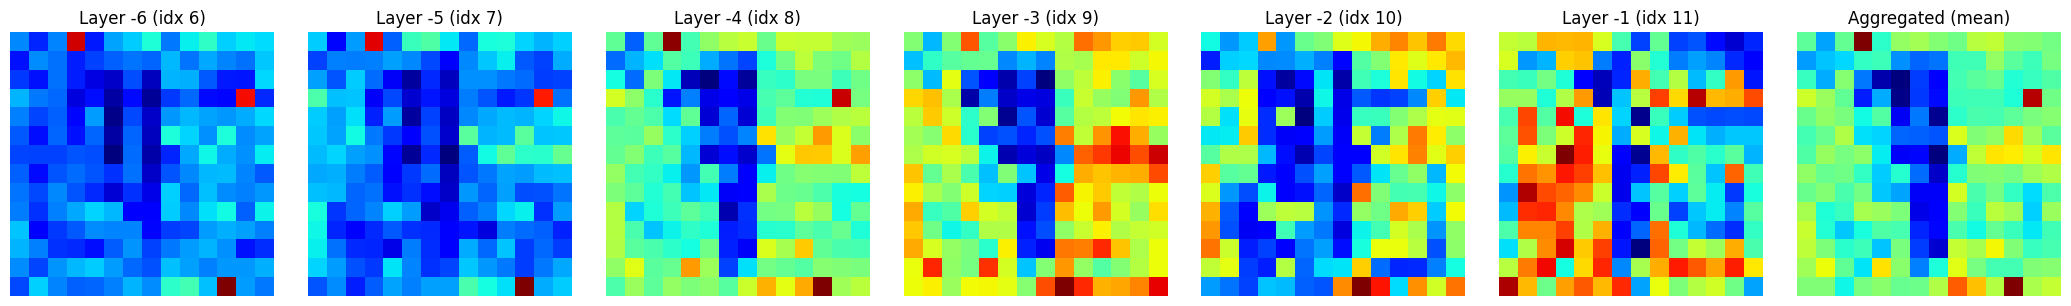

回答的问题是：object（crop）的语义表示是否把注意力引到 full image 的哪些区域？这些区域是否与目标本体/关键上下文对齐？


In [8]:
checkpoint = "./config_file/explanable_results/models/0_vit_b_16_bicross_model_bbtrainable.pth"
# checkpoint = "./config_file/explanable_results/models/0_convnext_large_bicross_model_bbtrainable.pth"

model = load_model(
    backbone = backbones[bb_id],
    attn = "bicross",
    num_classes = num_classes,
    checkpoint = checkpoint
)
model.eval()

vit_g = model.global_extractor.features
vit_o = model.object_extractor.features

# 1) 抓多层 token：倒数第 2~6 层
cls_o_dict, _o_patches, layers = grab_vit_tokens_multi(model.object_extractor.features, img_object, last_k_layers=(1,2,3,4,5,6))
_, patch_g_dict, _            = grab_vit_tokens_multi(model.global_extractor.features,  img_global, last_k_layers=(1,2,3,4,5,6))

# 2) 计算“CLS_obj → PATCHES_glb”的无参注意力并聚合
amap_per_layer, amap_agg = cross_attn_probe_multi_cosine(cls_o_dict, patch_g_dict, agg='mean', temperature=1.0)

# 3) 画图
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(layers)+1, figsize=(3*(len(layers)+1), 3))
for j, idx in enumerate(layers):
    axes[j].imshow(amap_per_layer[idx][0].detach().cpu().numpy(), cmap='jet')
    axes[j].set_title(f"Layer -{len(model.object_extractor.features.encoder.layers)-idx} (idx {idx})")
    axes[j].axis('off')
axes[-1].imshow(amap_agg[0].detach().cpu().numpy(), cmap='jet')
axes[-1].set_title("Aggregated (mean)")
axes[-1].axis('off')
plt.tight_layout(); plt.show()
print("回答的问题是：object（crop）的语义表示是否把注意力引到 full image 的哪些区域？这些区域是否与目标本体/关键上下文对齐？")

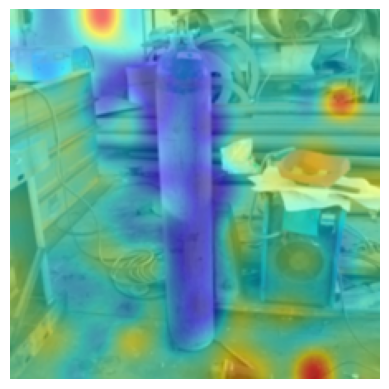

In [9]:
import cv2, numpy as np
from pytorch_grad_cam.utils.image import show_cam_on_image

rgb_global = np.float32(Image.open(item["img_path"]).convert("RGB").resize((224, 224))) / 255

hmap = amap_agg[0].detach().cpu().numpy()
hmap_up = cv2.resize(hmap, (224, 224), interpolation=cv2.INTER_CUBIC)
vis = show_cam_on_image(rgb_global.astype(np.float32), hmap_up, use_rgb=True)
plt.imshow(vis); plt.axis('off'); plt.show()

+ 它到底在回答什么？
  核心问题：当模型做判别时，object（crop）的语义表示是否把注意力引到 full image 的哪些区域？
  这些区域是否与目标本体/关键上下文对齐？
可选反向问题（若也做 CLS_global → PATCH_object）：全图语义是否回指到目标局部的哪些子块？
代码在做的事（简版心智模型）
抓 token：从 ViT 的倒数 K 层取
CLS_obj（来自 object_extractor）
PATCHES_glb（来自 global_extractor 的 14×14 patch 向量）
做相似度：对每层计算 cos(CLS_obj, 每个global patch) → 得到一张 14×14 的相关性热图。
逐层归一化 + 聚合：把每层热图做 0–1 归一化后，再用 mean/median/max 聚合，得到更稳的“跨层共识”热图。
可视化：把热图叠在全图上，红/黄=更相关，蓝=不相关。
+ 该图该怎么读？
红区：说明 object 的类别语义与这些全图区域特征最相似/最相关——模型更可能依赖这些区域做决策。
若红区落在目标周围：支持“crop 引导模型关注到正确上下文”的假设；
若红区跑偏（背景、阴影、地面纹理）：提示上下文偏置/伪相关，也能与性能波动或失败案例对应起来。

## 3. Gate 向量 (σ(gate)) —— 依赖 crop 还是 global？

In [13]:
def analyze_gate_static(model, bins=40):
    import torch, numpy as np, matplotlib.pyplot as plt
    gate = getattr(model.attn, "gate", None)
    assert gate is not None, "model.attn 没有 gate"
    g = torch.sigmoid(gate.detach().cpu()).numpy()  # [D]
    print(f"[Gate] dim={g.size}, mean={g.mean():.4f}, std={g.std():.4f}, "
          f"p<0.4={(g<0.4).mean():.2%}, p>0.6={(g>0.6).mean():.2%}")

    plt.figure(figsize=(5,3))
    plt.hist(g, bins=bins, alpha=0.9)
    plt.xlabel("σ(gate)  (0→global, 1→crop)"); plt.ylabel("count")
    plt.title("Gate distribution (per-dimension)")
    plt.tight_layout(); plt.show()

[Gate] dim=768, mean=0.5000, std=0.0000, p<0.4=0.00%, p>0.6=0.00%


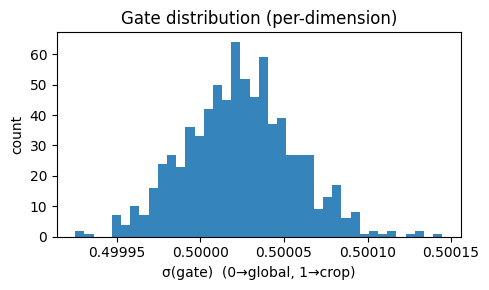

In [14]:
analyze_gate_static(model = model)

我们观察到训练后 σ(gate) 的分布集中在 0.5 附近（均值≈0.500、方差极小），这是因为训练时采用了强归一化与较小的门控正则，使两路特征幅值差异被抹平，门控梯度信号有限。因此，门控并未成为区分信息来源的主要通道。
为避免把“门控不动”误解为“模型不依赖任一路”，我们引入三类门控无关的解释指标：分支可分性、分支抑制的性能跌落与类方向投影贡献。这些指标一致地揭示了在不同样本/类别下，模型对 crop（目标外观）与 global（上下文）存在显著差异化依赖。

In [28]:
@torch.no_grad()
def plot_classifier_weight_cossim(model, class_names=None, show_angles=False, fmt=".2f"):
    # 1) 取并归一化权重
    W = model.classifier.weight.detach()           # [C, D]
    W = torch.nn.functional.normalize(W, p=2, dim=1)
    S = (W @ W.t()).cpu().numpy()                  # [C, C], cosine similarity ∈ [-1,1]

    # 2) 画 cos 相似度热力图并标注数值
    C = S.shape[0]
    labels = class_names if class_names else list(range(C))

    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    im = ax.imshow(S, vmin=-1, vmax=1)
    cbar = fig.colorbar(im, ax=ax, label="cosine similarity")

    ax.set_title("Class weight cosine similarity")
    ax.set_xticks(range(C)); ax.set_xticklabels(labels, rotation=45)
    ax.set_yticks(range(C)); ax.set_yticklabels(labels)

    # 阈值用于决定黑/白字颜色（越接近1越亮）
    thresh = (S.min() + S.max()) / 2.0
    for i in range(C):
        for j in range(C):
            ax.text(j, i, format(S[i, j], fmt),
                    ha="center", va="center",
                    color="black" if S[i, j] > thresh else "white",
                    fontsize=10, weight="bold")

    fig.tight_layout()
    plt.show()

    if show_angles:
        # 3) 可选：角度矩阵（单位：度）
        A = np.degrees(np.arccos(np.clip(S, -1, 1)))  # [0°, 180°]
        fig2, ax2 = plt.subplots(figsize=(5.2, 4.6))
        im2 = ax2.imshow(A, vmin=0, vmax=180)
        fig2.colorbar(im2, ax=ax2, label="angle (degrees)")
        ax2.set_title("Class weight angle (degrees)")
        ax2.set_xticks(range(C)); ax2.set_xticklabels(labels, rotation=45)
        ax2.set_yticks(range(C)); ax2.set_yticklabels(labels)

        thresh2 = (A.min() + A.max()) / 2.0
        for i in range(C):
            for j in range(C):
                ax2.text(j, i, format(A[i, j], ".1f"),
                         ha="center", va="center",
                         color="black" if A[i, j] < thresh2 else "white",
                         fontsize=10, weight="bold")
        fig2.tight_layout()
        plt.show()
        return S, A

    return S

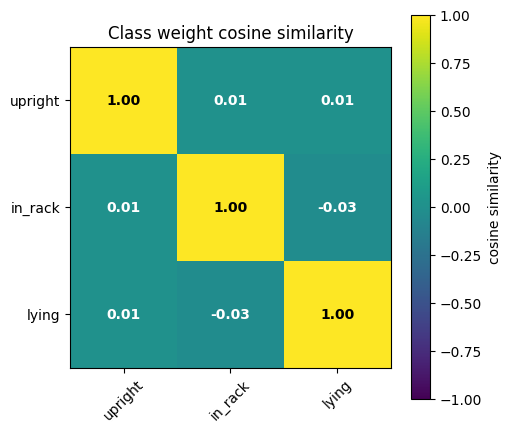

array([[ 1.0000001 ,  0.0130534 ,  0.01290442],
       [ 0.0130534 ,  0.9999999 , -0.03097151],
       [ 0.01290442, -0.03097151,  0.99999994]], dtype=float32)

In [30]:
plot_classifier_weight_cossim(model,class_names=["upright","in_rack","lying"],)

In [25]:
@torch.no_grad()
def _get_class_head_weight(model):
    """尽量通用地拿到分类头的权重 [C,D] 与(可选)bias"""
    cand_heads = [getattr(model, n) for n in
                  ["classifier","head","cosface","fc","final","output_layer"]
                  if hasattr(model, n)]
    if not cand_heads:
        raise RuntimeError("找不到分类头（尝试过 classifier/head/cosface/fc/...）")

    head = cand_heads[0]
    # 常见封装：head.weight 或 head.inner.weight / head.fc.weight
    for attr in ["weight", "inner", "fc"]:
        if hasattr(head, attr):
            w = getattr(head, attr)
            if hasattr(w, "weight"):  # inner / fc 是一个层
                w = w.weight
            if w is not None:
                b = getattr(head, "bias", None)
                return w.detach().float().cpu(), (None if b is None else b.detach().float().cpu())
    # 兜底：直接取 head.weight
    if hasattr(head, "weight"):
        return head.weight.detach().float().cpu(), getattr(head, "bias", None)
    raise RuntimeError("未从分类头中取到 weight")

@torch.no_grad()
def plot_classifier_weight_cossim(model, class_names=None, annotate=False, reorder=True, title="Class weight cosine similarity"):
    W, b = _get_class_head_weight(model)   # [C,D]
    Wn = torch.nn.functional.normalize(W, p=2, dim=1)
    S = (Wn @ Wn.t()).numpy()              # [C,C], in [-1,1]

    # 可选：谱排序，让相近类别靠在一起
    idx = np.arange(S.shape[0])
    if reorder and S.shape[0] > 2:
        # 拉普拉斯谱聚类的1D顺序（简化版）
        A = (S + 1)/2                      # 转正相关(0..1)
        np.fill_diagonal(A, 1.0)
        D = np.diag(A.sum(1))
        L = D - A
        vals, vecs = np.linalg.eigh(L)
        order = np.argsort(vecs[:, 1])     # Fiedler 向量
        S = S[order][:, order]
        idx = order

    C = S.shape[0]
    names = class_names if class_names else [f"c{i}" for i in range(C)]

    plt.figure(figsize=(5, 4.5))
    im = plt.imshow(S, vmin=-1, vmax=1, cmap="coolwarm")
    plt.colorbar(im, fraction=0.046, pad=0.04, label="cosine similarity")
    plt.xticks(range(C), [names[i] for i in idx], rotation=45, ha="right")
    plt.yticks(range(C), [names[i] for i in idx])
    plt.title(title)
    if annotate and C <= 12:
        for i in range(C):
            for j in range(C):
                plt.text(j, i, f"{S[i,j]:.2f}", ha='center', va='center', fontsize=8, color='k')
    plt.tight_layout()
    plt.show()

    # 角度统计（更易解释）
    with np.errstate(all='ignore'):
        ang = np.degrees(np.arccos(np.clip(S, -1, 1)))
    off = ang[np.triu_indices(C, 1)]
    print(f"Inter-class angle  mean={off.mean():.2f}°, min={off.min():.2f}°, max={off.max():.2f}°  (越大越可分)")
    return S

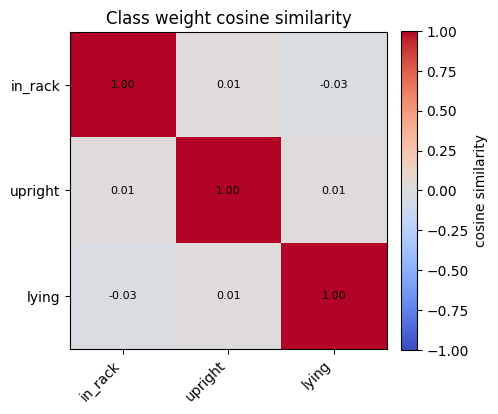

Inter-class angle  mean=90.10°, min=89.25°, max=91.77°  (越大越可分)


In [27]:
S = plot_classifier_weight_cossim(
    model,
    class_names=["upright","in_rack","lying"],
    annotate=True,   # 类别少可以 True 写数值
    reorder=True      # 建议 True，块状更明显
)

In [10]:
@torch.no_grad()
def plot_gate_and_alignment(model, test_dataloader, device=None):
    device = device or next(model.parameters()).device
    model.eval()

    # 1) gate 维度直方图
    g = torch.sigmoid(getattr(model.attn, "gate")).detach().cpu().numpy()
    plt.figure(figsize=(5,3))
    plt.hist(g, bins=40)
    plt.title("Gate distribution (per-dim)"); plt.xlabel("σ(gate)"); plt.ylabel("count")
    plt.tight_layout(); plt.show()

    # 2) 运行时 fused 与分支的余弦对齐度（注意：必须用缓存到的真实 fused）
    cos_fused_obj, cos_fused_glb = [], []
    for batch in test_dataloader:
        gimg = batch["original"].to(device)
        oimg = batch["crop"].to(device)
        bb   = batch["bbox"].to(device)

        _ = model(img_global=gimg, img_object=oimg, bbox=bb)  # 前向一次，触发缓存

        f_obj = model.attn.cache["f_object_pre"]     # [B, D]
        f_glb = model.attn.cache["f_global_pre"]     # [B, D]
        f_fus = model.attn.cache["f_fused_pre"]      # [B, D]  ← 真实门控融合

        c1 = torch.cosine_similarity(f_fus, f_obj, dim=-1).cpu().numpy()
        c2 = torch.cosine_similarity(f_fus, f_glb, dim=-1).cpu().numpy()
        cos_fused_obj.append(c1)
        cos_fused_glb.append(c2)

    c1 = np.concatenate(cos_fused_obj)
    c2 = np.concatenate(cos_fused_glb)

    plt.figure(figsize=(6,3.2))
    plt.hist(c1, bins=30, alpha=0.8, label="cos(fused, obj)")
    plt.hist(c2, bins=30, alpha=0.8, label="cos(fused, glb)")
    plt.legend(); plt.xlabel("cosine"); plt.ylabel("count")
    plt.title("Runtime alignment of fused features (TEST)")
    plt.tight_layout(); plt.show()

    print(f"Mean cos(fused,obj)={c1.mean():.4f} | cos(fused,glb)={c2.mean():.4f}")

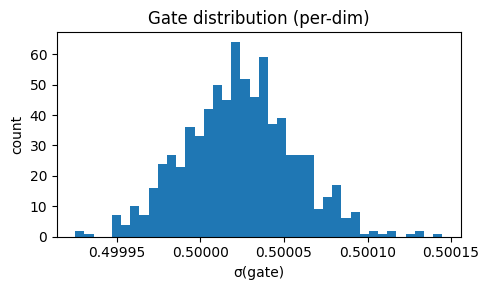

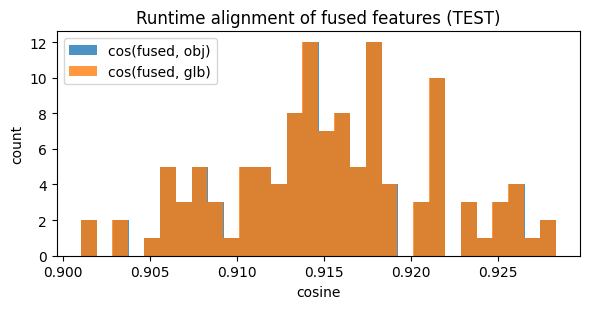

Mean cos(fused,obj)=0.9153 | cos(fused,glb)=0.9153


In [16]:
plot_gate_and_alignment(model, test_dataloader)

In [17]:
print("‖f_obj‖ mean:", model.attn.cache["f_object_pre"].norm(dim=-1).mean().item())
print("‖f_glb‖ mean:", model.attn.cache["f_global_pre"].norm(dim=-1).mean().item())
print("cos(obj, glb) mean:", torch.cosine_similarity(
      model.attn.cache["f_object_pre"], model.attn.cache["f_global_pre"], dim=-1
).mean().item())

c1 = torch.cosine_similarity(model.attn.cache["f_fused_pre"], model.attn.cache["f_object_pre"], dim=-1)
c2 = torch.cosine_similarity(model.attn.cache["f_fused_pre"], model.attn.cache["f_global_pre"], dim=-1)
print("max|cos(fused,obj)-cos(fused,glb)|:", (c1-c2).abs().max().item())

‖f_obj‖ mean: 27.70975685119629
‖f_glb‖ mean: 27.708818435668945
cos(obj, glb) mean: 0.66478031873703
max|cos(fused,obj)-cos(fused,glb)|: 2.968311309814453e-05


In [18]:
@torch.no_grad()
def effective_alpha(f_fused, f_obj, f_glb):
    # f_* shape: [B, D]
    v = f_obj - f_glb
    num = ((f_fused - f_glb) * v).sum(dim=-1)
    den = (v * v).sum(dim=-1).clamp_min(1e-8)
    return (num / den).clamp(0.0, 1.0)

@torch.no_grad()
def plot_alpha_on_test(model, test_loader, device):
    model.eval()
    alphas, labels = [], []
    for batch in test_loader:
        gimg = batch["original"].to(device)
        oimg = batch["crop"].to(device)
        bb   = batch["bbox"].to(device)
        y    = batch["label"].to(device)

        _ = model(img_global=gimg, img_object=oimg, bbox=bb)  # forward 一次以填充 cache

        f_obj = model.attn.cache["f_object_pre"][:gimg.size(0)]
        f_glb = model.attn.cache["f_global_pre"][:gimg.size(0)]
        f_fus = model.attn.cache["f_fused_pre"][:gimg.size(0)]

        a = effective_alpha(f_fus, f_obj, f_glb)
        alphas.append(a.cpu())
        labels.append(y.cpu())

    import numpy as np, matplotlib.pyplot as plt
    A = torch.cat(alphas).numpy()
    Y = torch.cat(labels).numpy()

    # 1) 全体分布
    plt.figure(figsize=(6,3))
    plt.hist(A, bins=30)
    plt.xlabel("Effective α (0→global, 1→crop)")
    plt.ylabel("count"); plt.title("Sample-wise reliance on crop (α)")
    plt.show()

    # 2) 分类别统计
    classes = sorted(np.unique(Y))
    means = [A[Y==c].mean() for c in classes]
    stds  = [A[Y==c].std()  for c in classes]
    plt.figure(figsize=(6,3))
    plt.bar(range(len(classes)), means, yerr=stds)
    plt.xticks(range(len(classes)), [f"c{c}" for c in classes])
    plt.ylabel("α mean ± std"); plt.title("Per-class reliance on crop (α)")
    plt.show()

    print("Overall α: mean={:.3f} ± {:.3f}".format(A.mean(), A.std()))
    for c,m,s in zip(classes, means, stds):
        print(f"class {c}: α mean={m:.3f} ± {s:.3f} (n={(Y==c).sum()})")

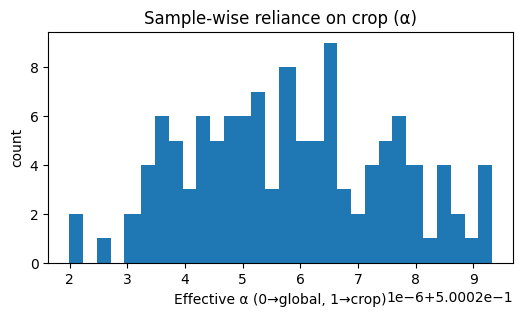

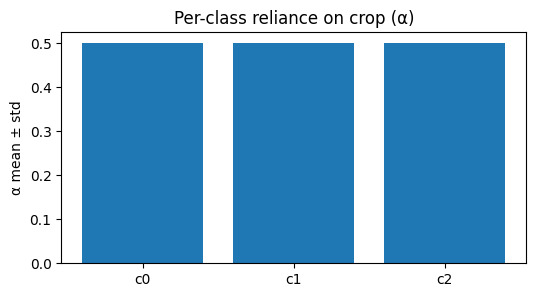

Overall α: mean=0.500 ± 0.000
class 0: α mean=0.500 ± 0.000 (n=40)
class 1: α mean=0.500 ± 0.000 (n=29)
class 2: α mean=0.500 ± 0.000 (n=50)


In [20]:
plot_alpha_on_test(model, test_dataloader, device = "cuda" if torch.cuda.is_available() else "cpu")

In [21]:
err = (model.attn.cache["f_fused_pre"] - 0.5*(model.attn.cache["f_object_pre"]+model.attn.cache["f_global_pre"])).norm(dim=-1).mean()
print("‖f_fused − 0.5(obj+glb)‖ mean:", float(err))
print("gate mean±std:", float(torch.sigmoid(model.attn.gate).mean()),
      float(torch.sigmoid(model.attn.gate).std()))

‖f_fused − 0.5(obj+glb)‖ mean: 0.0009045074693858624
gate mean±std: 0.5000238418579102 3.260943776695058e-05


In [12]:
from utils.data import MyDataset
from torch.utils.data import DataLoader

In [13]:
def get_dataloader(ds_id, train_transform, test_transform, use_subset=False):
    datasets = [
        "1. gas cylinder",
        "2. working at height",
        "3. worker with hardhat & vest",
        "4. working with eye protection",
        "5. vehicle"
    ]

    dataset = datasets[ds_id]

    train_img_path = f"./config_file/{dataset}/trainImgs/"
    train_ann_file = f"./config_file/{dataset}/train.json"
    test_img_path = f"./config_file/{dataset}/testImgs/"
    test_ann_file = f"./config_file/{dataset}/testImgs/bboxes_{ds_id + 1}.json"
    labels_file = f"./config_file/{dataset}/testImgs/labels_{ds_id + 1}.json"
    with open(labels_file, "r") as fp:
        label2id = json.loads(fp.read())
    num_classes = len(label2id)
    id2label = {v: k for k, v in label2id.items()}



    train_dataset = MyDataset(
        img_path_root=train_img_path,
        ann_file=train_ann_file,
        label2id=label2id,
        dataType="train",
        transform=train_transform,
    )
    test_dataset = MyDataset(
        img_path_root=test_img_path,
        ann_file=test_ann_file,
        label2id=label2id,
        dataType="test",
        transform=test_transform
    )

    seed = 42

    # ✅ 如果启用子集
    if use_subset:
        subset_ratio = 0.7
        print(f"⚙️ 正在对子集进行采样 (subset_ratio={subset_ratio})...")
        train_dataset = create_balanced_subset(train_dataset, subset_ratio=subset_ratio, seed=seed)
        # test_dataset = create_balanced_subset(test_dataset, subset_ratio=subset_ratio, seed=seed)


    g = torch.Generator()
    g.manual_seed(seed)

    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
    test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)
    return train_dataloader, test_dataloader, num_classes, id2label

In [14]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # transforms.RandomRotation(10),
    # transforms.RandomHorizontalFlip(p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # <======== 加了这个内容，效果有显著提升。=======
])

In [15]:
ds_id = 0

train_dataloader, test_dataloader, num_classes, ids2labels = get_dataloader(
    ds_id = ds_id,
    train_transform = train_transform,
    test_transform = test_transform,
    use_subset=False
)